# Вариант №21
Найти точку минимума функции
$$
f(x_1, x_2) = 2x^2_1 + 4x_1 + 3x^2_2 − 39.0x_2 + 129.75, \\
[x_1 = 0, x_2 = −3].
$$
методом Ньютона.
В окрестности точки минимума построить линии уровня и траекторию поиска (на одном графике). За своевременное выполнение задания начисляется 6 баллов.

Реализовав дополнительно следующие методы можно получить по 3 балла за каждый метод: 
- метод случайного поиска +
- метод Нелдера-Мида 
- метод Пауэлла +
- метод Хука-Дживса +
- метод Розенброка +

Для того, чтобы лабораторная работа была засчитана требуется оформление отчета (с формулами) с описанием используемых методов в формате Jupyter+Markdown+LaTeX.

Найдём минимум функции аналитически. 
$$ f(x_1, x_2) = 2x^2_1 + 4x_1 + 3x^2_2 − 39.0x_2 + 129.75 = 2(x^2 + 2x) + 3(y^2 - 13y) =\\
 2(x+1)^2 + 3(y - 6,5)^2 + 1
$$
Функция представляет собой гиперболический парабалойд. Он имеет один минимум - вершину.
$$ x + 1 = 0,\\y - 6,5\\
x_0 = -1, \quad y_0 = 6,5\\f_{min} = f(-1, 6.5) = 1 $$

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
Y_MIN_BOUND = -6
Y_MAX_BOUND =  5
X_MIN_BOUND = -2
X_MAX_BOUND =  5

In [3]:
x = np.linspace(-4, 5, 100)
y = x
x, y = np.meshgrid(x,y)
# z = 2*x**4 + 4 * x + 3 * y**4 - 39 * y + 129.75
# z = (1 - x)**2 + 100 * (y - x**2)**2
# z = y**4 + x**3 + x**2 * y**2 - x * y

# z = x**3 + 30 *x**2 + 6 *x*y + 264 * x + 8 * y**2 - 144*y**2 + 924*y - 1087

z = x**3 - 3*x +2*y**2 + x * y

In [4]:
def f(x_):
    x = x_[0]
    y = x_[1]
    return x**3 - 3*x +2*y**2 + x * y

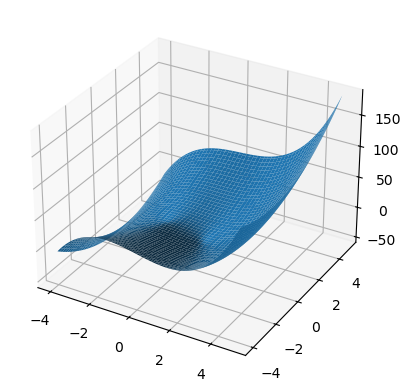

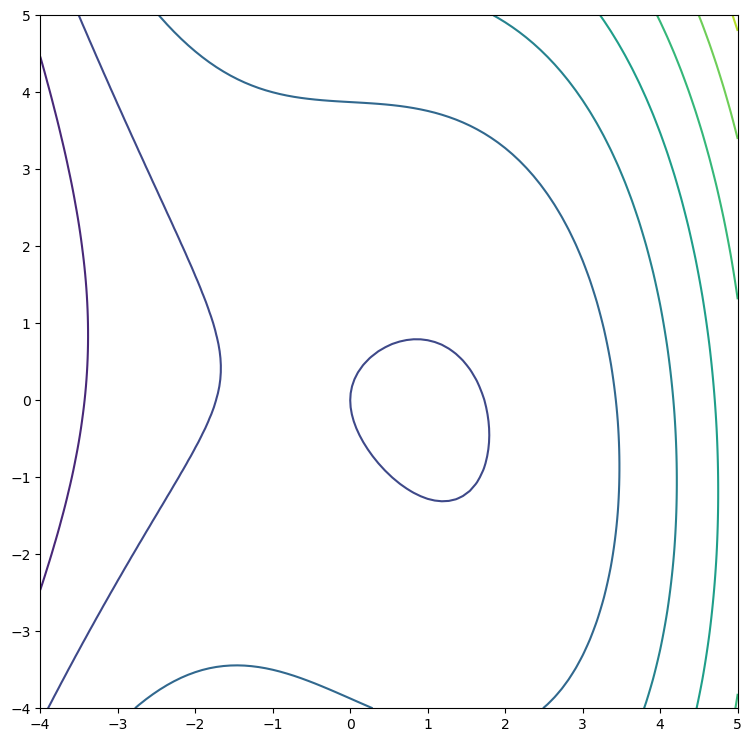

In [5]:
fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')
figu.plot_surface(x, y, z, label='sin')
# f.set(zlim=(0, 10))
# figu.contour(x, y, z)
plt.figure(figsize=(9, 9))

plt.contour(x, y, z)

# plt.plot([0,5], [0, 5])



# Метод случайного поиска
Идея: Генерируем $N$ точек в области определения функции и находим значение функции в этих точках, находим точку в которой функция принемает минимальное значение(назовём её "лучшая"), будем считать её минимумом функции.

# Метод Ньютона
    return 2*xy[0]**4 + 4 * xy[0] + 3 * xy[1]**3 - 39 * xy[1] + 129.75
$$
f(x_1, x_2) = 2x^4_1 + 4x_1 + 3x^4_2 − 39.0x_2 + 129.75, \\
[x^0_1 = 0, x^0_2 = −3].
$$

Метод Ньютона для поиска экстремума функции:
$$ \vec{x}^{k+1} = \vec{x}^k + p^k $$

$$ p^k = -[\nabla^2 f(x^k)]^{-1} \nabla f(x^k) $$
Перейдём к системе линейных уравнений относительно $p^k$
$$ [\nabla^2 f(x^k)] p^k = -\nabla f(x^k) $$

Матрица Гессе - матрица, состоящая из вторых производных функции
$$
[\nabla^2 f(x^k)] = 
\begin{pmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2 } \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2}
\end{pmatrix}
$$


# Дополнительная функция $f$
$$f(x,y) = x^3 - 3x + 2y^2 + xy$$

Аналитически найдём часные производные функции $f$:

$ \frac{\partial f}{\partial x} = 3x^2 - 3 + y $

$ \frac{\partial f}{\partial y} = 4y + x $

$\frac{\partial^2 f}{\partial x^2} = 6x $ 

$\frac{\partial^2 f}{\partial x \partial y} = 1 $

$\frac{\partial^2 f}{\partial y^2} = 4 $

Запишем матрицу Гессе и набла для нашей функции:
$$
[\nabla^2 f(x^k)] = 
\begin{pmatrix}
6x & 1 \\
1 & 4
\end{pmatrix} \\
\nabla f(x^k) = 
\begin{pmatrix}
3x^2 - 3 + y \\
4y + x
\end{pmatrix}
$$

In [6]:
# def nabl(x):
#     res = np.zeros((2, 1))
#     res[0] = 8 * x[0]**3 + 4
#     res[1] = 36 * x[1]**2 - 39
#     return res

In [7]:
# def nabl(xy):
#     """Градиент функции (частные производные)"""
#     # df/dx1 = 8*x1^3 + 4
#     df_dx1 = 8 * xy[0]**3 + 4
#     # df/dx2 = 12*x2^3 - 39
#     df_dx2 = 12 * xy[1]**3 - 39
#     return np.array([[df_dx1[0]], [df_dx2[0]]]) if isinstance(xy, np.ndarray) and xy.shape == (2,1) else np.array([[df_dx1], [df_dx2]])

# # Вычисляем гессиан (вторые производные)
# def Gesse(xy):
#     """Гессиан функции (матрица вторых производных)"""
#     # d2f/dx1^2 = 24*x1^2
#     d2f_dx1_2 = 24 * xy[0]**2
#     # d2f/dx1dx2 = 0
#     d2f_dx1dx2 = 0
#     # d2f/dx2dx1 = 0
#     d2f_dx2dx1 = 0
#     # d2f/dx2^2 = 36*x2^2
#     d2f_dx2_2 = 36 * xy[1]**2
    
#     return np.array([[d2f_dx1_2[0] if isinstance(d2f_dx1_2, np.ndarray) else d2f_dx1_2, 
#                       d2f_dx1dx2],
#                      [d2f_dx2dx1, 
#                       d2f_dx2_2[0] if isinstance(d2f_dx2_2, np.ndarray) else d2f_dx2_2]])

In [8]:
# def Gesse(x):
#     g = np.zeros((2,2))

#     # np.array([
#     #     [24*x[0]**2, 0],
#     #     [0, 12*x[1]**2]
#     # ])
#     # g[0][0] = 24*x[0][0]**2
#     g[1][1] = 12*x[1][0]**2
#     return g

# Gesse((-40, 0)), np.linalg.inv([[12, 0], [0, 6]])

In [9]:
# # def f(x1, x2):
# #     return x1**2 + 4 * x1 + 3 * x2**2 - 39 * x2 + 129.75
# # def f(xy):
# #     return 2*xy[0]**4 + 4 * xy[0] + 3 * xy[1]**4 - 39 * xy[1] + 129.75

# def f(x):
#     """Целевая функция (например, функция Розенброка)"""
#     # f(x,y) = (1-x)^2 + 100*(y-x^2)^2
#     return np.array([(1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2])

# def nabl(x):
#     """Градиент функции"""
#     dfdx1 = 3 * x[0]- 3 + x[1]
#     dfdx2 = 4 * x[1] + x[0]
#     return np.array([[dfdx1[0]], [dfdx2[0]]])

# def Gesse(x):
#     """Гессиан функции"""
#     d2fdx1_2 = 6 * x[0]
#     d2fdx1dx2 = 1
#     d2fdx2dx1 = 1
#     d2fdx2_2 = 4
    
#     return np.array([[d2fdx1_2, d2fdx1dx2],
#                      [d2fdx2dx1, d2fdx2_2]])

In [10]:
# Определяем функции (работают с векторами (2,))
def f(x):
    return x[0]**3 - 3*x[0] + 2*x[1]**2 + x[0]*x[1]

# def f(x_):
#     x = x_[0]
#     y = x_[1]

#     return 2 * x**2 + 4 * x + 3 * y**2 - 39 * y + 129.75

def nabl(x):
    dfdx1 = 3*x[0]**2 - 3 + x[1]
    dfdx2 = 4*x[1] + x[0]
    return np.array([dfdx1, dfdx2])

def Gesse(x):
    d2fdx1_2 = 6 * x[0]
    d2fdx1dx2 = 1
    d2fdx2dx1 = 1
    d2fdx2_2 = 4
    return np.array([[d2fdx1_2, d2fdx1dx2],
                     [d2fdx2dx1, d2fdx2_2]])

Итерация 0: x=[ 4.08376963 -1.02094241], f=53.769783
Итерация 1: x=[ 2.18663089 -0.54665772], f=3.297496
Итерация 2: x=[ 1.34765759 -0.3369144 ], f=-1.822405
Итерация 3: x=[ 1.07817785 -0.26954446], f=-2.126495
Итерация 4: x=[ 1.0431472 -0.2607868], f=-2.130354
Итерация 5: x=[ 1.04253453 -0.26063363], f=-2.130355


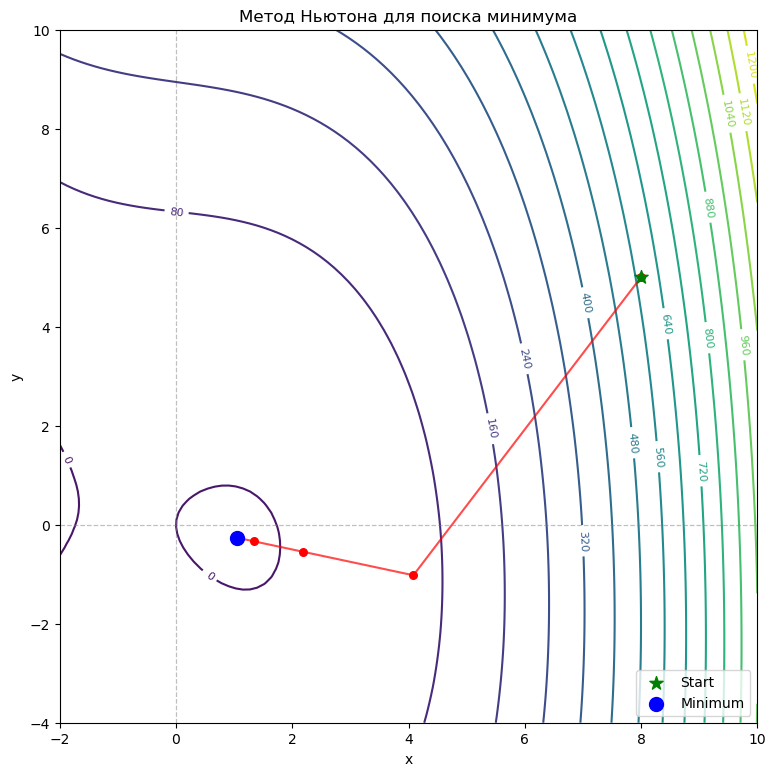


Найденный минимум:
x = 1.042535
y = -0.260634
f_min = -2.130355
Итераций: 6


In [11]:
# Начальная точка (вектор-столбец (2,1) приводим к (2,))
x_0 = np.array([8, 5.0])  # (2,) а не (2,1)
Eps = 0.001

x_current = x_0.copy()
x_next = x_0.copy()

# Создаем сетку для контурного графика
x_range = np.linspace(-2, 10, 100)
y_range = np.linspace(-4, 10, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f([X, Y])  # вычисляем значения функции на сетке

plt.figure(figsize=(9, 9))

# Контурный график
cs = plt.contour(X, Y, Z, levels=20)
plt.clabel(cs, inline=True, fontsize=8)

dots = [x_0]
iters = 0

while np.linalg.norm(nabl(x_next)) > Eps and iters < 50:
    x_current = x_next.copy()
    
    gesse = Gesse(x_current)
    
    # Регуляризация
    if np.linalg.cond(gesse) > 1e10:
        gesse = gesse + np.eye(2) * 1e-6
    
    # Шаг метода Ньютона
    try:
        p_k = np.linalg.solve(gesse, -nabl(x_current))
    except np.linalg.LinAlgError:
        print("Гессиан вырожден, останов")
        break
    
    x_next = x_current + p_k
    
    dots.append(x_next.copy())
    
    print(f"Итерация {iters}: x={x_next}, f={f(x_next):.6f}")
    iters += 1

# Извлекаем координаты для графика
x_vals = [dot[0] for dot in dots]
y_vals = [dot[1] for dot in dots]

# Рисуем траекторию
plt.scatter(x_vals, y_vals, c='red', s=30, zorder=5)
plt.plot(x_vals, y_vals, 'r-', linewidth=1.5, alpha=0.7)

# Начальная точка
plt.scatter(x_0[0], x_0[1], c='green', s=100, marker='*', label='Start', zorder=5)

# Конечная точка
plt.scatter(x_vals[-1], y_vals[-1], c='blue', s=100, marker='o', label='Minimum', zorder=5)

# Оси
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Метод Ньютона для поиска минимума')
plt.legend()

plt.show()

print(f'\nНайденный минимум:')
print(f'x = {x_vals[-1]:.6f}')
print(f'y = {y_vals[-1]:.6f}')
print(f'f_min = {f(dots[-1]):.6f}')
print(f'Итераций: {iters}')

In [12]:
f((-2, 6.5))

69.5

# переопределяем функцию $f$

In [13]:
def f(x_):
    x = x_[0]
    y = x_[1]

    return 2 * x**2 + 4 * x + 3 * y**2 - 39 * y + 129.75

# Метод Розенброка

Идея метода заключается в том, что выбирается система ортогональных направлений $p^k_1 , p^k_2, ..., p^k_n$, в каждом из которых последовательно ищется минимальное значение, после чего система направлений поворачивается так, чтобы одна из осей совпала с направлением полного перемещения, а остальные были ортогональны между собой. Алгоритм Розенброка состоит из двух этапов:
## Покоординатный спуск. 

Пусть $x^k$ - вектор $k$-приближения и $p^k_1 , p^k_2, ..., p^k_n$ - система ортогональных направлений. На первой итерации это может быть ортонормированная система координат. Начиная с заданного $x^k$ последовательно осуществляем минимизацию функции $f(x)$ в направлениях, соответстствующих $p^k_1 , p^k_2, ..., p^k_n$, находя последовательные приближения:
$$
x^{k+1}_1 = x^k_1 + \lambda^k_1p^k_1, \qquad \lambda^k_1 = \arg \min_{-\infty < \alpha < \infty} f(x^k + \alpha p^k_1) \\
\cdots \\
x^{k+1}_n = x^k_n + \lambda^k_n p^k_n, \qquad \lambda^k_n = \arg \min_{-\infty < \alpha < \infty} f(x^k + \alpha p^k_n)
$$

In [14]:
def scalarMult(a, b):
    res = 0
    for i in range(len(a)):
        res += a[i] * b[i]
    return res

def proj(v, u):  # проекция v на u
    coef = scalarMult(v, u) / scalarMult(u, u)
    return [coef * el for el in u]  # умножаем на u (направление)

In [15]:
def gram_schmidt_rosenbrock(A):
    n = len(A)
    Q = np.zeros_like(A)
    
    for i in range(n):
        q = A[i].copy()
        for j in range(i):
            q = q - np.dot(A[i], Q[j]) / np.dot(Q[j], Q[j]) * Q[j]
        Q[i] = q
    
    return Q

In [16]:
def sum_vectors(a, b):
    res = np.zeros(len(a))
    for i in range(len(a)):
        res[i] = a[i] + b[i]
    return res

In [17]:
def line_search(x, direction):
    alpha = 1.0 
    best_alpha = 0.0
    best_f = f(x)
    
    # Пробуем положительные шаги
    for _ in range(100):
        current_alpha = alpha
        current_f = f(x + current_alpha * direction)
        
        if current_f < best_f:
            best_f = current_f
            best_alpha = current_alpha
            alpha *= 1.5  # Увеличиваем шаг
        else:
            alpha *= 0.5  # Уменьшаем шаг
        
        if alpha < 1e-10 or alpha > 100:  # Защита от расходимости
            break
    
    # Пробуем отрицательные шаги
    alpha = -0.5
    for _ in range(100):
        current_alpha = alpha
        current_f = f(x + current_alpha * direction)
        
        if current_f < best_f:
            best_f = current_f
            best_alpha = current_alpha
            alpha *= 1.5
        else:
            alpha *= 0.5
        
        if abs(alpha) < 1e-10 or abs(alpha) > 100:  # Защита
            break
    
    return best_alpha

In [18]:
def rosenbrock(x0, max_iter=100, eps=1e-6):
    x = np.array(x0, dtype=float)
    n = len(x)
    

    p = np.eye(n)
    dots = [x.copy()]
    
    for iteration in range(max_iter):
        x_old = x.copy()
        lambdas = np.zeros(n)
        
        for i in range(n):
            direction = p[i]
            lam = line_search(x, direction)
            lambdas[i] = lam
            x = x + lam * direction
            dots.append(x.copy())
        
        # Проверка сходимости
        distance = np.linalg.norm(x - x_old)
        print(f'Итерация {iteration+1}: x={x}, f(x)={f(x):.6f}')
        
        if distance < eps:
            break
        
        nonzero = np.abs(lambdas) > 1e-12
        
        if np.any(nonzero):
            # Строим накопленные перемещения
            A = np.zeros((n, n))
            for i in range(n):
                for j in range(i, n):
                    A[i] += lambdas[j] * p[j]

            p_new = gram_schmidt_rosenbrock(A)
            p_new = np.array(p_new)
            
            # Обновляем направления
            for i in range(n):
                if np.linalg.norm(p_new[i]) > 1e-12:
                    p[i] = p_new[i] / np.linalg.norm(p_new[i])
            
            p = p_new.copy()
    
    return x, f(x), iteration+1, dots

Начальная точка: x_0 = [-9 -9]
Итерация 1: x=[-1.40625    8.0859375], f(x)=8.875671
Итерация 2: x=[-1.04845814  6.48825923], f(x)=1.005110
Итерация 3: x=[-0.9957436   6.50497982], f(x)=1.000111
Итерация 4: x=[-0.99960201  6.49999608], f(x)=1.000000
Итерация 5: x=[-0.99994113  6.50000953], f(x)=1.000000
Итерация 6: x=[-1.00000516  6.50000079], f(x)=1.000000
Итерация 7: x=[-1.00000044  6.49999985], f(x)=1.000000
Итерация 8: x=[-0.99999995  6.50000004], f(x)=1.000000
Найденный минимум: x1 = -0.999999948171998, x2 = 6.500000039137157
Значение функции: 1.0
Число итераций: 8


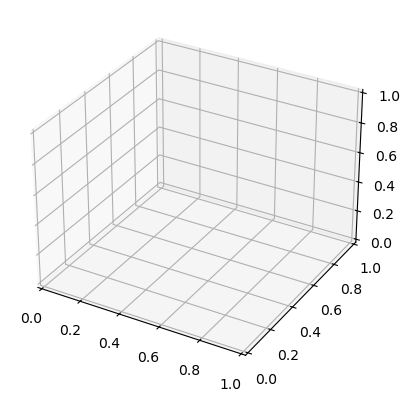

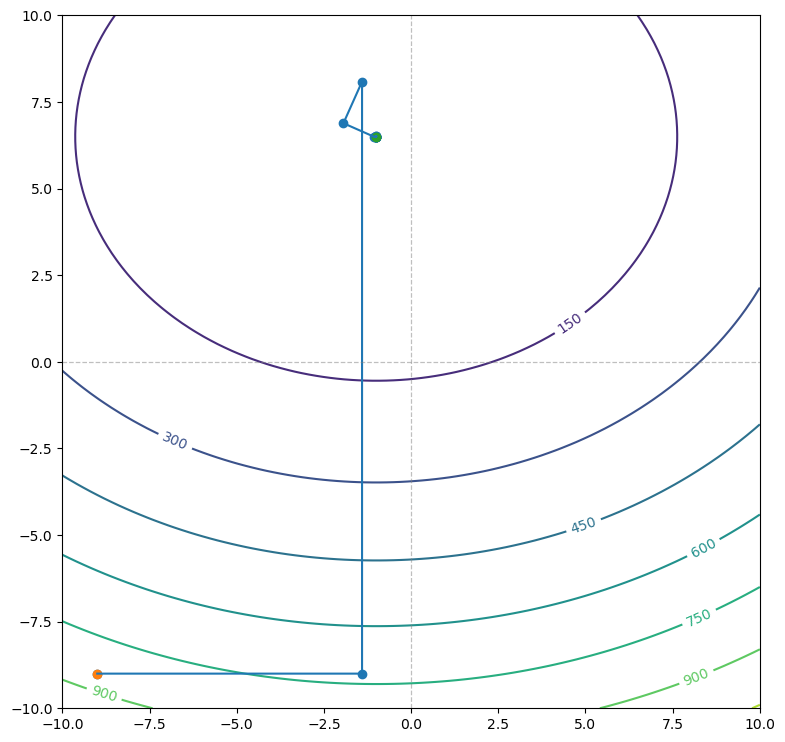

In [19]:
# Запуск
x0 = np.array([-9, -9])  # далеко от минимума
print(f'Начальная точка: x_0 = {x0}')
x_min, f_min, iters, dots = rosenbrock(x0)

print(f"Найденный минимум: x1 = {x_min[0]}, x2 = {x_min[1]}")
print(f"Значение функции: {f_min}")
print(f"Число итераций: {iters}")

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

plt.figure(figsize=(9, 9))


x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
x, y = np.meshgrid(x,y)


z = 2 * x**2 + 4 * x + 3 * y**2 - 39 * y + 129.75
cs = plt.contour(x, y, z)
plt.clabel(cs)

x_ = [dot[0] for dot in dots]
y_ = [dot[1] for dot in dots]

plt.plot(x_, y_)
plt.scatter(x_, y_)

plt.scatter(x0[0], x0[1])
plt.scatter(x_min[0], x_min[1])

plt.plot([0, 0], [-10, 10], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([-10, 10], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

# Метод Пауэлла

Последовательно выполнять одномерную минимизацию вдоль системы линейно независимых направлений, постепенно заменяя их на сопряжённые, что обеспечивает квадратичную сходимость.

In [20]:
def sumMult(x, y, b):
    return [x[i] + b * y[i] for i in range(2)] # x + b*y

[5, 5]
[-0.96228027  6.5703125 ]
[-1.00034404  6.50013733]
[-0.99997741  6.49998927]
[-0.99999995  6.50000012]
Минимум в точке: [-1.00000002  6.5       ]
Значение функции: 0.9999999999999716
Итераций: 4


[[5, 5],
 array([-0.96228027,  6.5703125 ]),
 array([-1.00034404,  6.50013733]),
 array([-0.99997741,  6.49998927]),
 array([-0.99999995,  6.50000012]),
 array([-1.00000002,  6.5       ])]

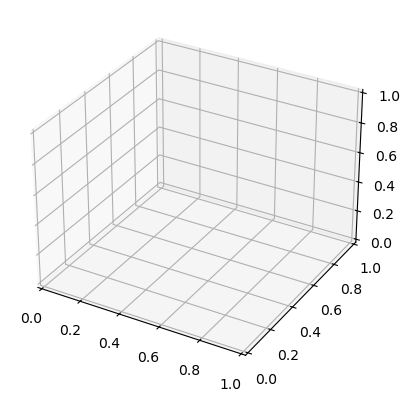

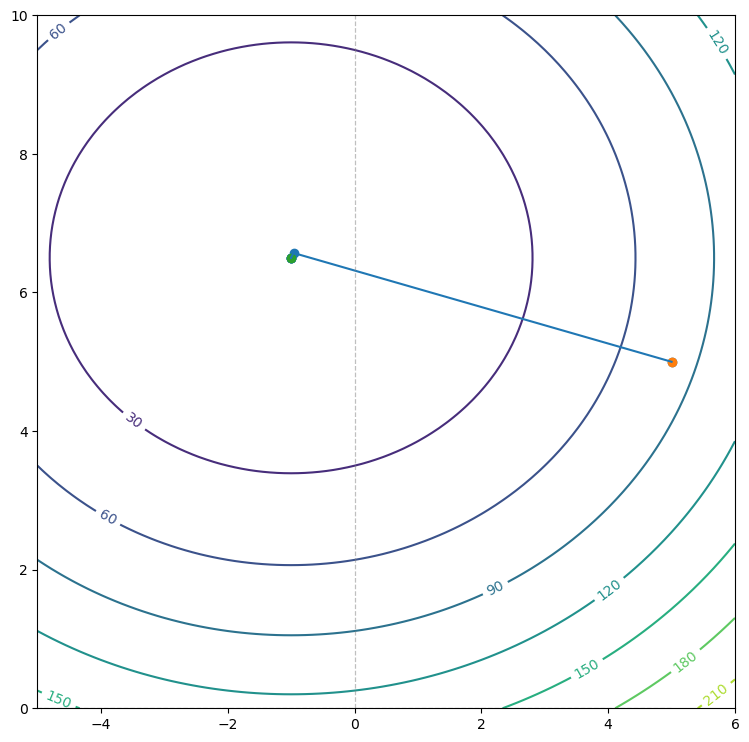

In [21]:
def powell(x0, iters=10, eps=1e-6):
    x = np.array(x0, dtype=float)
    
    dots = [x0]
    p = np.eye(2)  # начальные направления
    
    for iteration in range(iters):
        print(dots[-1])
        x_start = x.copy()
        
        # Шаг 1: поиск вдоль всех направлений
        for i in range(2):
            lam = line_search(x, p[i])
            x = x + lam * p[i]
        
        x_end = x.copy()
        d_new = x_end - x_start
        
        # Шаг 2: проверка замены направлений
        x_test = 2*x_end - x_start
        if f(x_test) >= f(x_start):
            # не меняем направления
            pass
        else:
            # меняем направления
            
            p[0] = p[1]
            p[1] = d_new
            lam = line_search(x_end, p[1])
            x = x_end + lam * p[1]
        dots.append(x)
        # Шаг 3: проверка сходимости
        if np.linalg.norm(x - x_start) < eps:
            break
        
    return x, f(x), iteration, dots


x0 = [5,5]


x_min, f_min, it, dots = powell(x0)
print(f"Минимум в точке: {x_min}")
print(f"Значение функции: {f_min}")
print(f"Итераций: {it}")

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

plt.figure(figsize=(9, 9))


x = np.linspace(-5, 6, 100)
y = np.linspace(-0, 10, 100)
x, y = np.meshgrid(x,y)


z = 2 * x**2 + 4 * x + 3 * y**2 - 39 * y + 129.75
cs = plt.contour(x, y, z)
plt.clabel(cs)

x_ = [dot[0] for dot in dots]
y_ = [dot[1] for dot in dots]

plt.plot(x_, y_)
plt.scatter(x_, y_)

plt.scatter(x0[0], x0[1])
plt.scatter(x_min[0], x_min[1])

plt.plot([0, 0], [0, 10], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([-5, 5], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

dots

In [22]:
def HookeJeeves(x0, step=0.01, max_iteration=100, Eps=1e-6):
    x = np.array(x0)
    
    n = 2 # кол-во переменных
    
    dots = [x0.copy()]
    iteration = 0

    for iteration in range(max_iteration):
        x_start = x.copy()

        x_base = x.copy()
        h = np.full(n, step)

        for i in range(n):
            #  шаг вперед
            x[i] += h[i]
            if f(x) < f(x_base):
                continue  # Оставляем изменение
            
            #  шаг назад
            x[i] -= 2 * h[i]
            if f(x) < f(x_base):
                continue  # Оставляем изменение
            
            # Возвращаем как было
            x[i] += h[i]
            
        if np.array_equal(x, x_base):
            step /= 2

        p_k = x - x_base

        alpha  = line_search(x, p_k)

        x = x + alpha * p_k
        
        dots.append(x)

        if np.linalg.norm(x - x_start) < Eps:
            break


    return x, iteration+1, dots

Начальная точка: x_0 = [-9 -9]
Найденный минимум: x1 = -0.9967089843750414, x2 = 6.498720703124936
Значение функции: 0.9999999999999716
Число итераций: 11


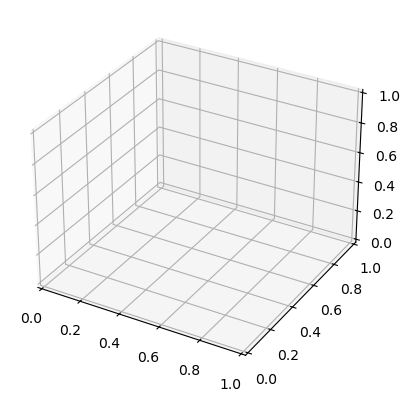

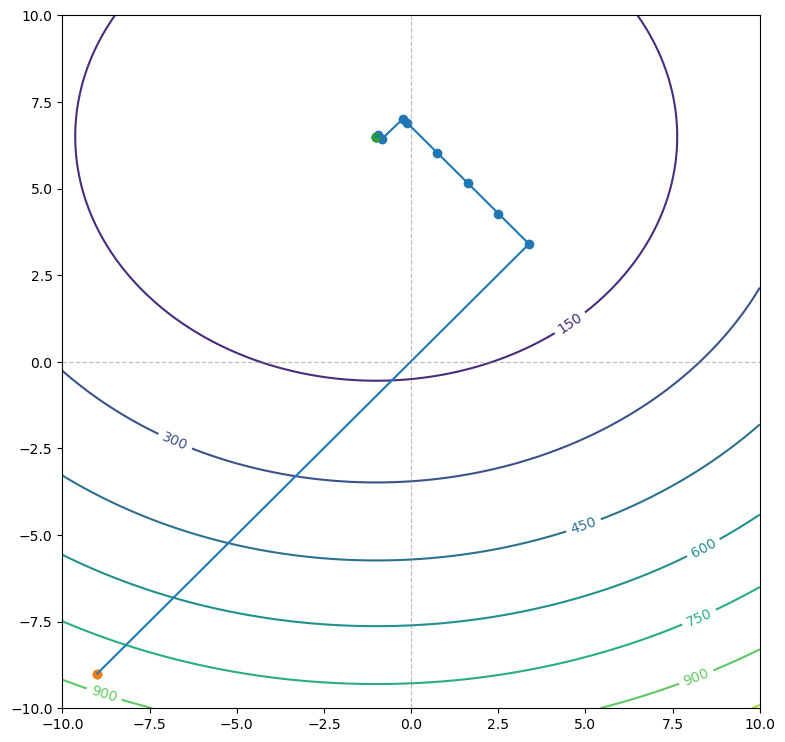

In [23]:
# Запуск
x0 = np.array([-9, -9])  
print(f'Начальная точка: x_0 = {x0}')
x_min, iters, dots = HookeJeeves(x0)

print(f"Найденный минимум: x1 = {x_min[0]}, x2 = {x_min[1]}")
print(f"Значение функции: {f_min}")
print(f"Число итераций: {iters}")

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

plt.figure(figsize=(9, 9))


x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
x, y = np.meshgrid(x,y)


z = 2 * x**2 + 4 * x + 3 * y**2 - 39 * y + 129.75
cs = plt.contour(x, y, z)
plt.clabel(cs)

x_ = [dot[0] for dot in dots]
y_ = [dot[1] for dot in dots]

plt.plot(x_, y_)
plt.scatter(x_, y_)

plt.scatter(x0[0], x0[1])
plt.scatter(x_min[0], x_min[1])

plt.plot([0, 0], [-10, 10], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([-10, 10], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

In [ ]:
import random

def normalRandVect():

    p = np.zeros(2)
    r_angle = random.uniform(0, 2 * np.pi)
    p[0] = np.cos(r_angle)
    p[1] = np.sin(r_angle)

    return p

In [45]:
def getAngleOfRandVect():
    x = random.random() * 2 - 1
    y = random.random() * 2 - 1

    norm = np.sqrt(x**2 + y**2)
    return np.arctan((y/norm) / (x/norm))

In [58]:
N_r = 1000

angles = [getAngleOfRandVect() for _ in range(N_r)]

av = np.average(angles)

Dx = 0
for a in angles:
    Dx += (a - av)**2

Dx /= N_r

# sigma = 
print(f'мат ожидание: {av} | {0}')
print(f'дисперсия: {Dx} | {(np.pi)**2 / 12}')
print(f'{np.abs(Dx - (np.pi)**2 / 12)}')
# print(f'Средне квадратичное откл: {sigma}')
print(f'мат ожидание: {av}')

мат ожидание: 0.024456137632913433 | 0
дисперсия: 0.7863378497884878 | 0.8224670334241132
0.03612918363562545
мат ожидание: 0.024456137632913433


In [57]:
normalRandVect()

array([ 0.60711355, -0.79461509])

# Метод случайного поиска

На каждой итерации выбираем вектор $\overline{p}$ случайного направления движения (угол $\phi \in [0, 2 \pi]$), после ищем оптимальный шаг в этом направлении. остановка производится по расстаянию между двумя шагами.

In [59]:
def randomSearch(x0, Eps=1e-6, max_iters=200):

    p = normalRandVect()
    
    x = np.array(x0)
    
    # print(f'{x=}')
    alha = line_search(x, p)
    x_next = x + alha * p

    iters = 1
    dots = [x0.copy(), x]

    while np.linalg.norm(x_next - x) > Eps and iters < max_iters:

        # print(f'{x=}, {alha=}')
        x = x_next
        p = normalRandVect()
        
        alha = line_search(x, p)
        x_next = x + alha * p
        iters += 1
        dots.append(x_next)

    return x, iters, dots

Результат работы Метода случайного поиска:
Итераций: 32
Полученная точка: 
x = -1.0000012101209446
y = 6.500000091248089
f_min = 1.0000000000029559


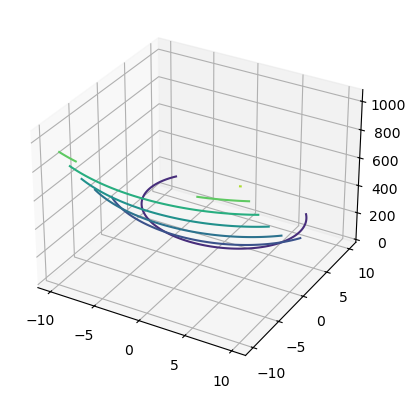

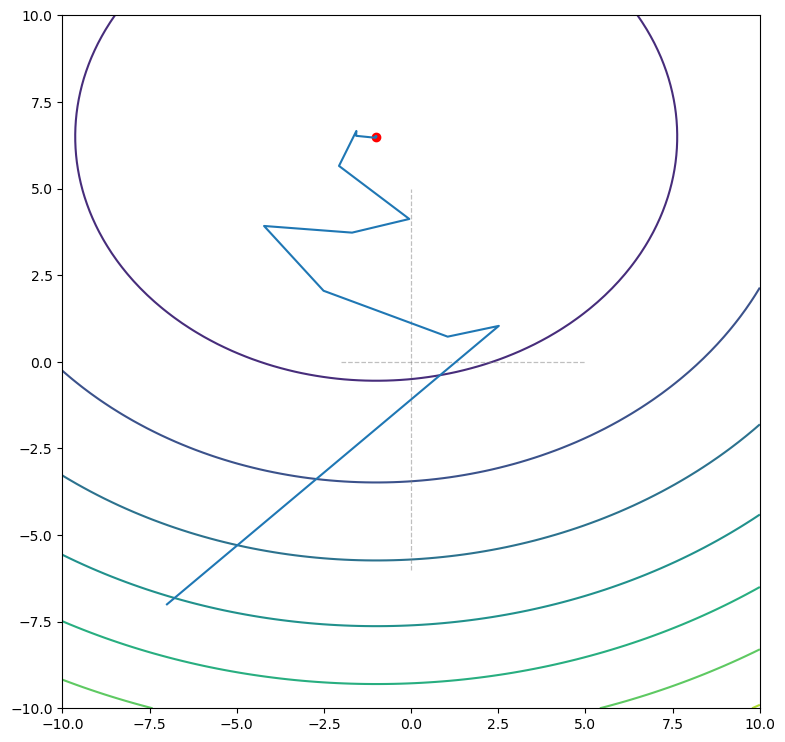

In [62]:
x0 = [-7, -7]

res, iters, dots = randomSearch(x0)

fig = plt.figure()
figu = fig.add_subplot(111, projection='3d')

# f.set(zlim=(0, 10))
figu.contour(x, y, z)
plt.figure(figsize=(9, 9))

plt.contour(x, y, z)

plt.plot([0, 0], [Y_MIN_BOUND, Y_MAX_BOUND], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)
plt.plot([X_MIN_BOUND, X_MAX_BOUND], [0, 0], color='gray', linestyle='--', linewidth=0.9, alpha=0.5)

X_dots = [dot[0] for dot in dots]
Y_dots = [dot[1] for dot in dots]
plt.plot(X_dots, Y_dots)
plt.scatter(res[0], res[1], color='red')


print(f'Результат работы Метода случайного поиска:')
print(f'Итераций: {iters}')
print(f'Полученная точка: \nx = {res[0]}\ny = {res[1]}\nf_min = {f(res)}')